In [1]:
import numpy as np
from PIL import Image
import matplotlib.pyplot as plt

#I WANT TO TEST THIS

## (Colab only) Unpack data from Google Drive

Running on a local kernel, `train/` and `train_labels.csv` already sit next to this notebook. Running on a **Colab kernel**, the remote runtime can't see your local files — upload `melanoma_data.zip` to your Google Drive once (drag it into drive.google.com), then the cell below mounts your Drive and unzips it into `/content` each session (falls back to a directly-uploaded `/content/melanoma_data.zip` if you'd rather use "Upload to Colab" instead). This is a no-op when there's no Colab runtime.

In [2]:
import os

if os.path.isdir('/content'):
    os.chdir('/content')
    if not os.path.isdir('train'):
        DRIVE_ZIP_PATH = '/content/drive/MyDrive/melanoma_data.zip'  # adjust if you put it elsewhere in Drive

        from google.colab import drive
        drive.mount('/content/drive')

        zip_source = DRIVE_ZIP_PATH if os.path.exists(DRIVE_ZIP_PATH) else 'melanoma_data.zip'
        assert os.path.exists(zip_source), (
            f"Couldn't find the data zip at {DRIVE_ZIP_PATH} or /content/melanoma_data.zip — "
            "upload melanoma_data.zip to your Google Drive (or directly to Colab) first"
        )
        get_ipython().system(f'unzip -q "{zip_source}"')
    print('data ready in', os.getcwd())

Mounted at /content/drive
data ready in /content


## Reading Files

In [3]:
import os
import pandas as pd

TRAIN_DIR = 'train'

# list every jpg in the train folder, strip extension to get the image_name key
train_files = [f for f in os.listdir(TRAIN_DIR) if f.lower().endswith('.jpg')]
files_df = pd.DataFrame({
    'image_name': [os.path.splitext(f)[0] for f in train_files],
    'image_path': [os.path.join(TRAIN_DIR, f) for f in train_files],
})

print(f'{len(files_df)} jpg files found in {TRAIN_DIR}/')
files_df.head()

6864 jpg files found in train/


,image_name,image_path
0,ISIC_4253846,train/ISIC_4253846.jpg
1,ISIC_6641007,train/ISIC_6641007.jpg
2,ISIC_5399478,train/ISIC_5399478.jpg
3,ISIC_7519274,train/ISIC_7519274.jpg
4,ISIC_8897947,train/ISIC_8897947.jpg


In [4]:
labels_df = pd.read_csv('train_labels.csv')

# join filenames with their labels on image_name
data_df = files_df.merge(labels_df, on='image_name', how='inner')

print(f'{len(data_df)} images matched to a label (of {len(files_df)} files, {len(labels_df)} label rows)')
data_df.shape

6864 images matched to a label (of 6864 files, 6864 label rows)


(6864, 9)

## Bar Chat of class balance

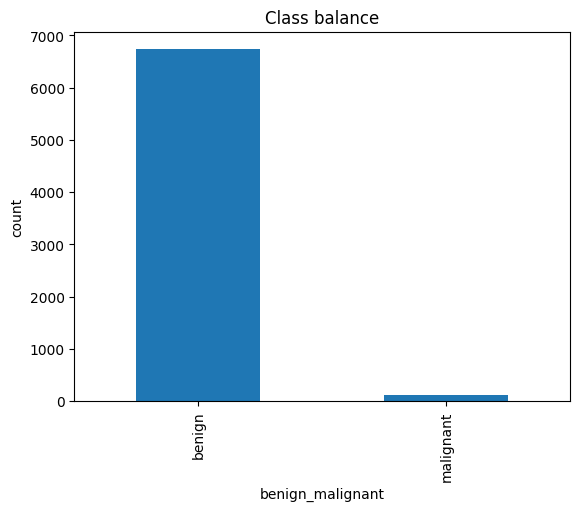

,count
benign_malignant,
benign,6736
malignant,128


In [5]:
data_df['benign_malignant'].value_counts().plot(kind='bar', title='Class balance')
plt.ylabel('count')
plt.show()

data_df['benign_malignant'].value_counts()

## Example Of loaded images


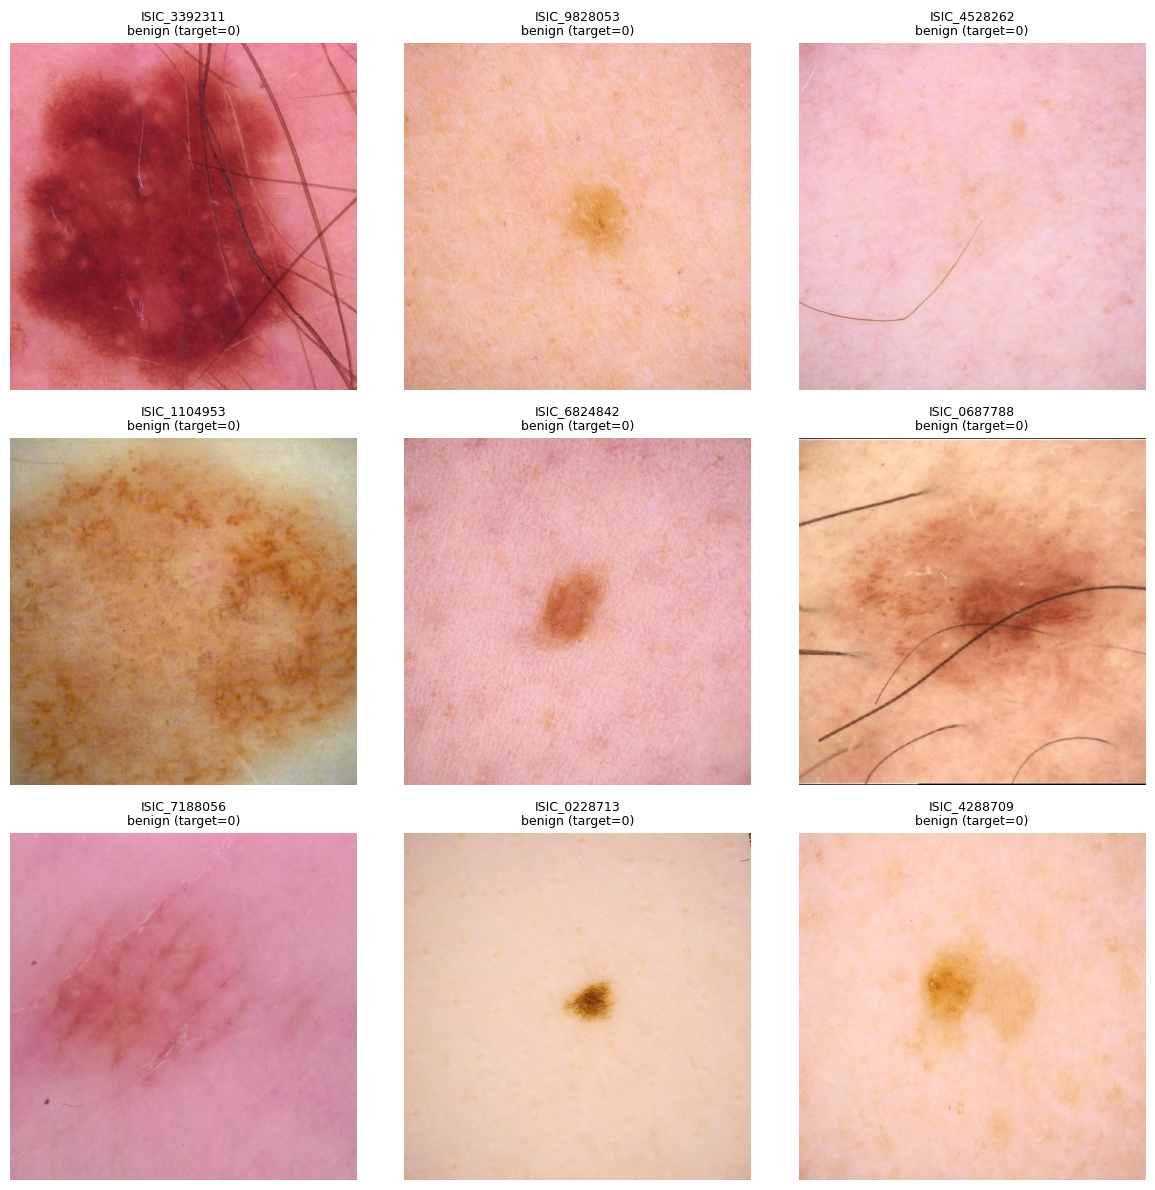

In [6]:
def show_sample_grid(df, n=9, seed=42):
    sample = df.sample(n=n, random_state=seed)
    cols = 3
    rows = -(-n // cols)
    fig, axes = plt.subplots(rows, cols, figsize=(4 * cols, 4 * rows))
    for ax, (_, row) in zip(axes.flat, sample.iterrows()):
        img = Image.open(row['image_path']).convert('RGB')
        ax.imshow(img)
        ax.set_title(f"{row['image_name']}\n{row['benign_malignant']} (target={row['target']})", fontsize=9)
        ax.axis('off')
    for ax in axes.flat[len(sample):]:
        ax.axis('off')
    plt.tight_layout()
    plt.show()

show_sample_grid(data_df, n=9)

## Image-only dataset (patient_id, image_path, target)

In [7]:
image_df = data_df[['patient_id', 'image_path', 'target']].copy()
image_df.head()

,patient_id,image_path,target
0,IP_3055814,train/ISIC_4253846.jpg,0
1,IP_2986217,train/ISIC_6641007.jpg,0
2,IP_7584179,train/ISIC_5399478.jpg,0
3,IP_0454573,train/ISIC_7519274.jpg,0
4,IP_0974501,train/ISIC_8897947.jpg,0


## Load images into memory (resized)

All 6864 images are 512x512 RGB (~423MB of jpgs on disk, ~5.4GB uncompressed at full res — too much to hold as one array). For a baseline CNN, resizing down to 128x128 first and loading everything into memory as `X`/`y` numpy arrays is simpler than a lazy generator/pipeline and small enough to fit comfortably (~340MB). Bump `IMG_SIZE` up later once the baseline works if you want more detail.

In [8]:
IMG_SIZE = 224

def load_images(df, img_size=IMG_SIZE):
    X = np.empty((len(df), img_size, img_size, 3), dtype=np.uint8)
    for i, path in enumerate(df['image_path']):
        with Image.open(path) as img:
            img = img.convert('RGB').resize((img_size, img_size))
            X[i] = np.array(img)
    y = df['target'].to_numpy()
    return X, y

X, y = load_images(image_df)
print(X.shape, X.dtype, y.shape, f'{X.nbytes / 1e6:.0f} MB')

(6864, 224, 224, 3) uint8 (6864,) 1033 MB


## Augmentation function

In [9]:
import albumentations as A
import numpy as np

# Transforms chosen to preserve diagnostic color signal —
# no hue/saturation shifts, only geometric + mild intensity changes
melanoma_augment = A.Compose([
    A.HorizontalFlip(p=0.5),
    A.VerticalFlip(p=0.5),
    A.Rotate(limit=30, border_mode=0, p=0.7),  # border_mode=0 pads with black
    A.RandomBrightnessContrast(brightness_limit=0.1, contrast_limit=0.1, p=0.5),
    A.ShiftScaleRotate(shift_limit=0.05, scale_limit=0.1, rotate_limit=0, p=0.5),
    A.GaussianBlur(blur_limit=(3, 5), p=0.2),  # mild — simulates focus variation
])

def augment_minority_class(images, labels, target_class=1, n_target=None, seed=42):
    """
    Generates augmented copies of images belonging to `target_class` to
    help balance the dataset. Only call this on a TRAINING split — never
    on validation/test folds.

    Parameters
    ----------
    images : np.ndarray, shape (N, H, W, C)
    labels : np.ndarray, shape (N,)
    target_class : the minority class label to augment (e.g. 1 = melanoma)
    n_target : desired total count of target_class after augmentation.
               If None, matches the majority class count.
    seed : for reproducibility

    Returns
    -------
    aug_images : np.ndarray of newly generated images (originals not included)
    aug_labels : np.ndarray of the corresponding label (all == target_class)
    """
    rng = np.random.default_rng(seed)

    minority_mask = labels == target_class
    minority_imgs = images[minority_mask]
    n_minority = len(minority_imgs)

    if n_target is None:
        n_majority = len(labels) - n_minority
        n_target = n_majority

    n_to_generate = max(0, n_target - n_minority)

    aug_images = []
    for _ in range(n_to_generate):
        idx = rng.integers(0, n_minority)
        src_img = minority_imgs[idx]
        augmented = melanoma_augment(image=src_img)['image']
        aug_images.append(augmented)

    aug_images = np.array(aug_images) if aug_images else np.empty((0, *images.shape[1:]))
    aug_labels = np.full(len(aug_images), target_class)

    return aug_images, aug_labels

/usr/local/lib/python3.13/dist-packages/albumentations/core/validation.py:114: UserWarning: ShiftScaleRotate is a special case of Affine transform. Please use Affine transform instead.
  original_init(self, **validated_kwargs)


## Train/Test Split

Only 422 unique `patient_id`s cover all 6864 images (~16 images/patient on average). A plain random split could put the same patient's images in both train and test, letting the model leak patient-specific cues (skin tone, lighting, camera) instead of learning general lesion features. Splitting is done by **patient group** instead, using `StratifiedGroupKFold` to keep the malignant/benign ratio close between splits while guaranteeing no patient appears in both.

In [10]:
from sklearn.model_selection import StratifiedGroupKFold

splitter = StratifiedGroupKFold(n_splits=5, shuffle=True, random_state=42)
train_idx, test_idx = next(splitter.split(image_df, image_df['target'], groups=image_df['patient_id']))

X_train, X_test = X[train_idx], X[test_idx]
y_train, y_test = y[train_idx], y[test_idx]
train_df, test_df = image_df.iloc[train_idx], image_df.iloc[test_idx]

assert set(train_df['patient_id']) & set(test_df['patient_id']) == set()

print(f'train: {len(train_idx)} images, {train_df["patient_id"].nunique()} patients, {train_df["target"].mean():.2%} malignant')
print(f'test:  {len(test_idx)} images, {test_df["patient_id"].nunique()} patients, {test_df["target"].mean():.2%} malignant')


# target a 60/40 benign/malignant split in the augmented training set
target_minority_ratio = 0.4
n_majority = (y_train == 0).sum()
n_target_minority = int(round(n_majority * target_minority_ratio / (1 - target_minority_ratio)))

aug_imgs, aug_labels = augment_minority_class(X_train, y_train, target_class=1, n_target=n_target_minority)

X_train_balanced = np.concatenate([X_train, aug_imgs], axis=0)
y_train_balanced = np.concatenate([y_train, aug_labels], axis=0)

print(f'after augmentation: {len(X_train_balanced)} images, '
      f'{y_train_balanced.mean():.2%} malignant')

train: 5688 images, 338 patients, 1.81% malignant
test:  1176 images, 84 patients, 2.13% malignant
after augmentation: 9308 images, 40.00% malignant


## Visualize Augmented Images

A sample of malignant training images before and after passing through `melanoma_augment`, to sanity-check that the transforms look reasonable (still recognizably the same lesion, no weird color artifacts).

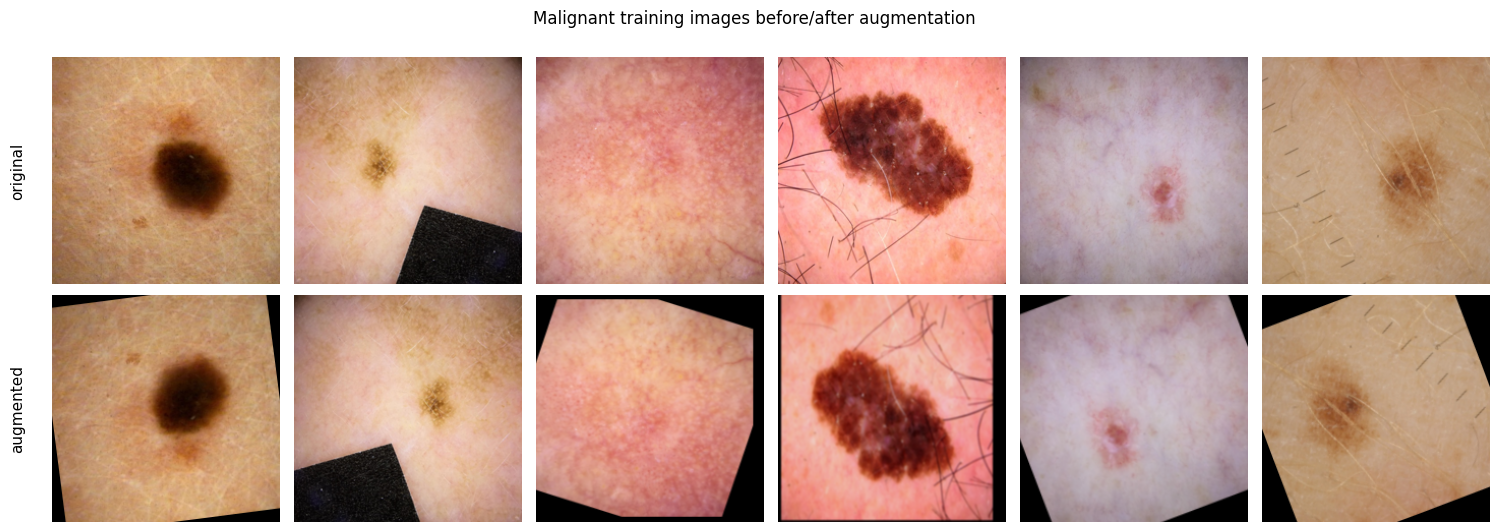

In [11]:
n_show = 6
minority_train_imgs = X_train[y_train == 1]

rng_vis = np.random.default_rng(0)
sample_idx = rng_vis.choice(len(minority_train_imgs), size=n_show, replace=False)

fig, axes = plt.subplots(2, n_show, figsize=(2.5 * n_show, 5.5))
for col, idx in enumerate(sample_idx):
    orig = minority_train_imgs[idx]
    augmented = melanoma_augment(image=orig)['image']

    axes[0, col].imshow(orig)
    axes[0, col].axis('off')
    axes[1, col].imshow(augmented)
    axes[1, col].axis('off')

axes[0, 0].text(-0.15, 0.5, 'original', transform=axes[0, 0].transAxes,
                rotation=90, va='center', ha='center', fontsize=11)
axes[1, 0].text(-0.15, 0.5, 'augmented', transform=axes[1, 0].transAxes,
                rotation=90, va='center', ha='center', fontsize=11)

fig.suptitle('Malignant training images before/after augmentation')
plt.tight_layout()
plt.show()

## Using logistic regression

In [12]:
import tensorflow as tf
from tensorflow.keras.applications import DenseNet121
from tensorflow.keras.applications.densenet import preprocess_input

def make_preprocessed_dataset(images, labels=None, batch_size=32, shuffle=False):
    """
    Streams `images` through DenseNet's preprocess_input in batches instead of
    converting the whole uint8 array to float32 up front — doing that for
    X_train_balanced (~9k images) needs ~5.4GB in one array, which is enough
    to OOM-crash a free-tier Colab runtime.
    """
    if labels is None:
        ds = tf.data.Dataset.from_tensor_slices(images)
        prep = lambda x: preprocess_input(tf.cast(x, tf.float32))
    else:
        ds = tf.data.Dataset.from_tensor_slices((images, labels))
        prep = lambda x, y: (preprocess_input(tf.cast(x, tf.float32)), y)

    if shuffle:
        ds = ds.shuffle(len(images), seed=42, reshuffle_each_iteration=True)

    return ds.map(prep, num_parallel_calls=tf.data.AUTOTUNE).batch(batch_size).prefetch(tf.data.AUTOTUNE)

feature_extractor = DenseNet121(
    weights='imagenet',
    include_top=False,
    input_shape=(IMG_SIZE, IMG_SIZE, 3),
    pooling='avg'   # GAP layer -> 1024-d vector
)
feature_extractor.trainable = False  # frozen, no fit() needed

feat_train = feature_extractor.predict(make_preprocessed_dataset(X_train_balanced), verbose=1)
feat_test  = feature_extractor.predict(make_preprocessed_dataset(X_test), verbose=1)

print(feat_train.shape, feat_test.shape)  # (n_samples, 1024)

29084464/29084464 ━━━━━━━━━━━━━━━━━━━━ 3s 0us/step
291/291 ━━━━━━━━━━━━━━━━━━━━ 56s 133ms/step
37/37 ━━━━━━━━━━━━━━━━━━━━ 15s 423ms/step
(9308, 1024) (1176, 1024)


In [13]:
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report, confusion_matrix, precision_recall_curve, roc_auc_score, average_precision_score
import numpy as np

# LR converges faster/more reliably on scaled features
scaler = StandardScaler()
feat_train_scaled = scaler.fit_transform(feat_train)
feat_test_scaled = scaler.transform(feat_test)

clf = LogisticRegression(max_iter=1000, random_state=42, class_weight='balanced')
clf.fit(feat_train_scaled, y_train_balanced)

y_prob = clf.predict_proba(feat_test_scaled)[:, 1]

# --- rank-based metrics, independent of any threshold choice ---
print(f"ROC-AUC: {roc_auc_score(y_test, y_prob):.4f}")
print(f"PR-AUC (average precision): {average_precision_score(y_test, y_prob):.4f}")

# --- default 0.5 threshold, for reference ---
y_pred_default = clf.predict(feat_test_scaled)
print("\n--- Default threshold (0.5) ---")
print(classification_report(y_test, y_pred_default, target_names=['benign', 'malignant']))
print('confusion matrix:\n', confusion_matrix(y_test, y_pred_default))

# --- sweep thresholds, pick the one that maximizes F1 for the malignant class ---
precisions, recalls, thresholds = precision_recall_curve(y_test, y_prob)
f1_scores = 2 * (precisions * recalls) / (precisions + recalls + 1e-8)
best_idx = np.argmax(f1_scores[:-1])  # last point has no corresponding threshold
best_threshold = thresholds[best_idx]

print(f"\nBest threshold by F1: {best_threshold:.3f} "
      f"(precision={precisions[best_idx]:.3f}, recall={recalls[best_idx]:.3f}, f1={f1_scores[best_idx]:.3f})")

y_pred_tuned = (y_prob >= best_threshold).astype(int)
print("\n--- Tuned threshold ---")
print(classification_report(y_test, y_pred_tuned, target_names=['benign', 'malignant']))
print('confusion matrix:\n', confusion_matrix(y_test, y_pred_tuned))

ROC-AUC: 0.7083
PR-AUC (average precision): 0.1100

--- Default threshold (0.5) ---
              precision    recall  f1-score   support

      benign       0.98      0.96      0.97      1151
   malignant       0.12      0.24      0.16        25

    accuracy                           0.95      1176
   macro avg       0.55      0.60      0.57      1176
weighted avg       0.96      0.95      0.96      1176

confusion matrix:
 [[1109   42]
 [  19    6]]

Best threshold by F1: 0.997 (precision=0.333, recall=0.120, f1=0.176)

--- Tuned threshold ---
              precision    recall  f1-score   support

      benign       0.98      0.99      0.99      1151
   malignant       0.33      0.12      0.18        25

    accuracy                           0.98      1176
   macro avg       0.66      0.56      0.58      1176
weighted avg       0.97      0.98      0.97      1176

confusion matrix:
 [[1145    6]
 [  22    3]]


### SVM

In [14]:
from sklearn.svm import SVC
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report, confusion_matrix, precision_recall_curve, roc_auc_score, average_precision_score
import numpy as np

# SVM also benefits from scaled features (same scaler pattern as LR)
scaler = StandardScaler()
feat_train_scaled = scaler.fit_transform(feat_train)
feat_test_scaled = scaler.transform(feat_test)

# probability=True is required to get predict_proba for threshold tuning/PR-AUC
# (it fits an internal 5-fold CV for Platt scaling, so this is slower than predict-only SVM)
clf_svm = SVC(kernel='rbf', class_weight='balanced', probability=True, random_state=42)
clf_svm.fit(feat_train_scaled, y_train_balanced)

y_prob_svm = clf_svm.predict_proba(feat_test_scaled)[:, 1]

# --- rank-based metrics, independent of threshold ---
print(f"ROC-AUC: {roc_auc_score(y_test, y_prob_svm):.4f}")
print(f"PR-AUC (average precision): {average_precision_score(y_test, y_prob_svm):.4f}")

# --- default 0.5 threshold ---
y_pred_default_svm = clf_svm.predict(feat_test_scaled)
print("\n--- Default threshold (0.5) ---")
print(classification_report(y_test, y_pred_default_svm, target_names=['benign', 'malignant']))
print('confusion matrix:\n', confusion_matrix(y_test, y_pred_default_svm))

# --- F1-optimal threshold, same approach as LR ---
precisions, recalls, thresholds = precision_recall_curve(y_test, y_prob_svm)
f1_scores = 2 * (precisions * recalls) / (precisions + recalls + 1e-8)
best_idx = np.argmax(f1_scores[:-1])
best_threshold = thresholds[best_idx]

print(f"\nBest threshold by F1: {best_threshold:.3f} "
      f"(precision={precisions[best_idx]:.3f}, recall={recalls[best_idx]:.3f}, f1={f1_scores[best_idx]:.3f})")

y_pred_tuned_svm = (y_prob_svm >= best_threshold).astype(int)
print("\n--- Tuned threshold ---")
print(classification_report(y_test, y_pred_tuned_svm, target_names=['benign', 'malignant']))
print('confusion matrix:\n', confusion_matrix(y_test, y_pred_tuned_svm))

ROC-AUC: 0.8733
PR-AUC (average precision): 0.2002

--- Default threshold (0.5) ---
              precision    recall  f1-score   support

      benign       0.98      0.99      0.99      1151
   malignant       0.29      0.16      0.21        25

    accuracy                           0.97      1176
   macro avg       0.63      0.58      0.60      1176
weighted avg       0.97      0.97      0.97      1176

confusion matrix:
 [[1141   10]
 [  21    4]]

Best threshold by F1: 0.136 (precision=0.333, recall=0.320, f1=0.327)

--- Tuned threshold ---
              precision    recall  f1-score   support

      benign       0.99      0.99      0.99      1151
   malignant       0.33      0.32      0.33        25

    accuracy                           0.97      1176
   macro avg       0.66      0.65      0.66      1176
weighted avg       0.97      0.97      0.97      1176

confusion matrix:
 [[1135   16]
 [  17    8]]


In [15]:
y_test_arr = np.asarray(y_test)
y_pred_arr = np.asarray(y_pred_tuned_svm)

tp_idx = np.where((y_test_arr == 1) & (y_pred_arr == 1))[0]  # correctly caught malignant
tn_idx = np.where((y_test_arr == 0) & (y_pred_arr == 0))[0]  # correctly caught benign
fp_idx = np.where((y_test_arr == 0) & (y_pred_arr == 1))[0]  # benign flagged as malignant
fn_idx = np.where((y_test_arr == 1) & (y_pred_arr == 0))[0]  # malignant missed — the dangerous one

print(f"TP: {len(tp_idx)}, TN: {len(tn_idx)}, FP: {len(fp_idx)}, FN: {len(fn_idx)}")

TP: 8, TN: 1135, FP: 16, FN: 17


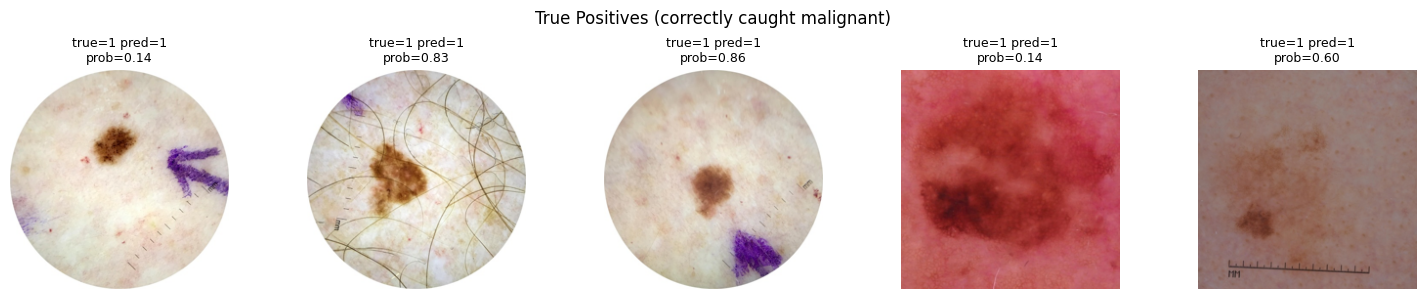

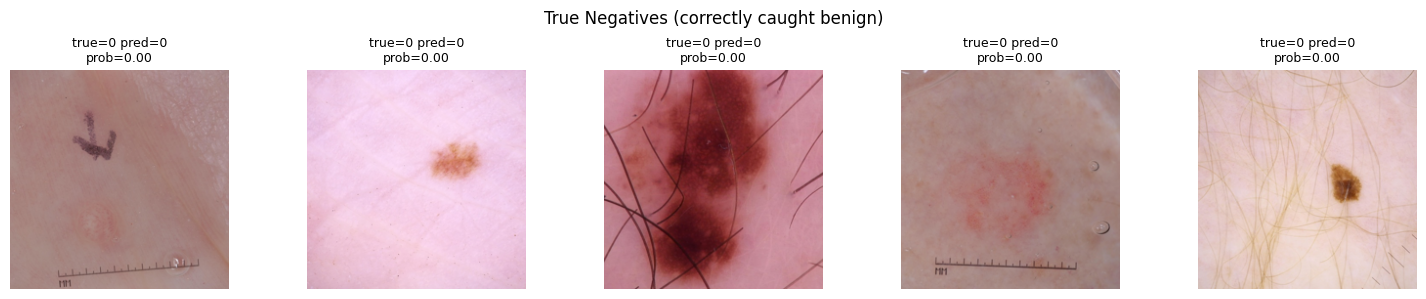

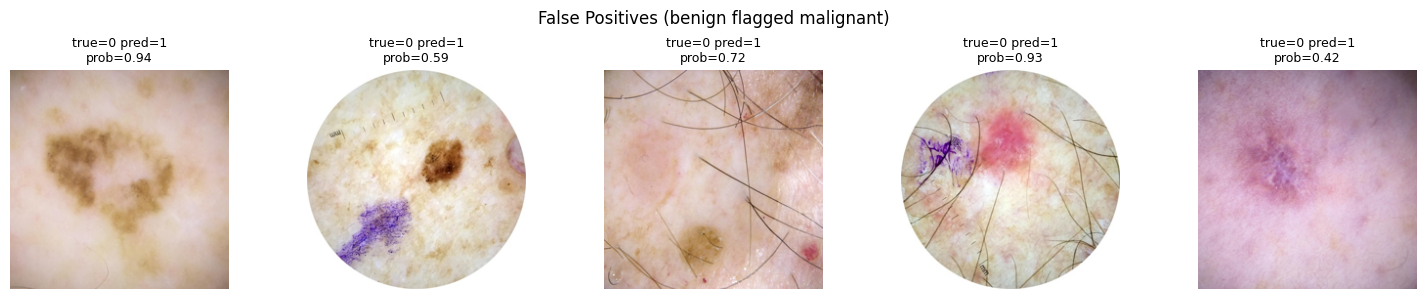

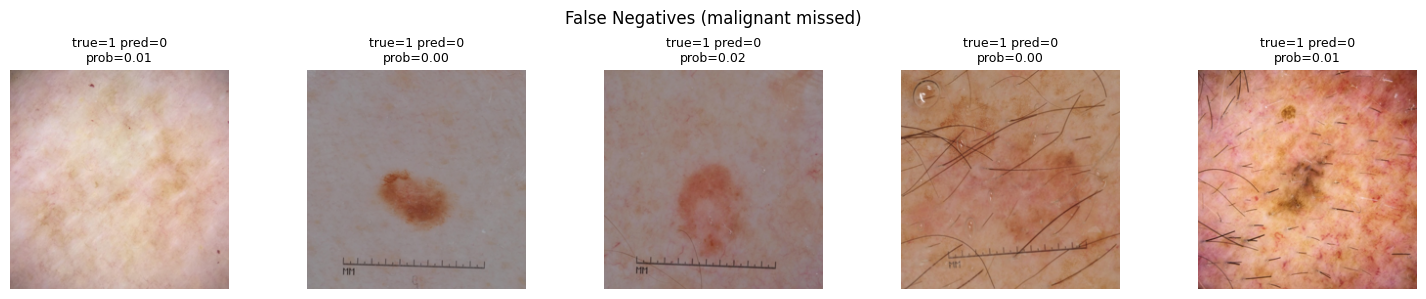

In [16]:
def show_examples(indices, X, y_true, y_pred, y_prob, title, n=5):
    n = min(n, len(indices))
    if n == 0:
        print(f"No examples for {title}")
        return
    fig, axes = plt.subplots(1, n, figsize=(3*n, 3))
    if n == 1:
        axes = [axes]
    for ax, idx in zip(axes, indices[:n]):
        ax.imshow(X[idx].astype('uint8'))
        ax.set_title(f"true={y_true[idx]} pred={y_pred[idx]}\nprob={y_prob[idx]:.2f}", fontsize=9)
        ax.axis('off')
    fig.suptitle(title)
    plt.tight_layout()
    plt.show()

show_examples(tp_idx, X_test, y_test_arr, y_pred_arr, y_prob_svm, "True Positives (correctly caught malignant)")
show_examples(tn_idx, X_test, y_test_arr, y_pred_arr, y_prob_svm, "True Negatives (correctly caught benign)")
show_examples(fp_idx, X_test, y_test_arr, y_pred_arr, y_prob_svm, "False Positives (benign flagged malignant)")
show_examples(fn_idx, X_test, y_test_arr, y_pred_arr, y_prob_svm, "False Negatives (malignant missed)")

In [17]:
from sklearn.metrics import precision_recall_curve, average_precision_score
import matplotlib.pyplot as plt

# precision, recall, thresholds = precision_recall_curve(y_test, y_prob)
# ap = average_precision_score(y_test, y_prob)

# plt.figure(figsize=(6, 5))
# plt.plot(recall, precision, label=f'AP = {ap:.3f}')
# plt.axhline(y=(y_test == 1).mean(), color='gray', linestyle='--', label='baseline (random)')
# plt.xlabel('Recall (sensitivity)')
# plt.ylabel('Precision')
# plt.title('Precision-Recall Curve')
# plt.legend()
# plt.grid(alpha=0.3)
# plt.show()

In [18]:
# from sklearn.metrics import precision_score, recall_score, f1_score

# thresholds_sweep = np.linspace(0.01, 0.99, 99)
# precisions, recalls, f1s = [], [], []

# for t in thresholds_sweep:
#     y_pred_t = (y_prob >= t).astype(int)
#     precisions.append(precision_score(y_test, y_pred_t, zero_division=0))
#     recalls.append(recall_score(y_test, y_pred_t, zero_division=0))
#     f1s.append(f1_score(y_test, y_pred_t, zero_division=0))

# plt.figure(figsize=(8, 5))
# plt.plot(thresholds_sweep, precisions, label='Precision')
# plt.plot(thresholds_sweep, recalls, label='Recall (sensitivity)')
# plt.plot(thresholds_sweep, f1s, label='F1-score')
# plt.axvline(x=0.5, color='gray', linestyle='--', alpha=0.5, label='default threshold')
# plt.xlabel('Decision threshold')
# plt.ylabel('Score')
# plt.title('Precision / Recall / F1 vs. Threshold')
# plt.legend()
# plt.grid(alpha=0.3)
# plt.show()

## DenseNet121 (trained on the balanced dataset)

Trains on `X_train_balanced`/`y_train_balanced` (original training images plus the augmented malignant copies from the "Train/Test Split" section, ~60/40 benign/malignant), still with only the channel-wise normalization `DenseNet121`'s pretrained ImageNet weights expect (`preprocess_input`; this is not augmentation, it's the fixed input scaling the pretrained weights were trained with). The pretrained base is frozen and only a new pooling + dense head is trained, so this reflects what the ImageNet features alone can do on this task once class imbalance is addressed via augmentation.

In [19]:
import tensorflow as tf
from tensorflow.keras import layers, models
from tensorflow.keras.applications import DenseNet121

base_model = DenseNet121(weights='imagenet', include_top=False, input_shape=(IMG_SIZE, IMG_SIZE, 3), pooling='avg')
base_model.trainable = False

model = models.Sequential([
    base_model,
    layers.Dense(1, activation='sigmoid'),
])

model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy', tf.keras.metrics.AUC(name='auc'), tf.keras.metrics.Precision(name='precision'), tf.keras.metrics.Recall(name='recall')],
)

model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ densenet121 (Functional)        │ (None, 1024)           │     7,037,504 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 1)              │         1,025 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 7,038,529 (26.85 MB)

 Trainable params: 1,025 (4.00 KB)

 Non-trainable params: 7,037,504 (26.85 MB)

In [20]:
train_ds = make_preprocessed_dataset(X_train_balanced, labels=y_train_balanced, batch_size=32, shuffle=True)
val_ds = make_preprocessed_dataset(X_test, labels=y_test, batch_size=32)

history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=10,
)

Epoch 1/10
291/291 ━━━━━━━━━━━━━━━━━━━━ 84s 208ms/step - accuracy: 0.9011 - auc: 0.9590 - loss: 0.2555 - precision: 0.9354 - recall: 0.8085 - val_accuracy: 0.9328 - val_auc: 0.8437 - val_loss: 0.2118 - val_precision: 0.1250 - val_recall: 0.3600
Epoch 2/10
291/291 ━━━━━━━━━━━━━━━━━━━━ 28s 95ms/step - accuracy: 0.9330 - auc: 0.9777 - loss: 0.1779 - precision: 0.9532 - recall: 0.8754 - val_accuracy: 0.9575 - val_auc: 0.8525 - val_loss: 0.1376 - val_precision: 0.1429 - val_recall: 0.2000
Epoch 3/10
291/291 ━━━━━━━━━━━━━━━━━━━━ 39s 90ms/step - accuracy: 0.9395 - auc: 0.9822 - loss: 0.1592 - precision: 0.9561 - recall: 0.8896 - val_accuracy: 0.9396 - val_auc: 0.8512 - val_loss: 0.1827 - val_precision: 0.1406 - val_recall: 0.3600
Epoch 4/10
291/291 ━━━━━━━━━━━━━━━━━━━━ 26s 90ms/step - accuracy: 0.9440 - auc: 0.9852 - loss: 0.1470 - precision: 0.9614 - recall: 0.8961 - val_accuracy: 0.9456 - val_auc: 0.8414 - val_loss: 0.1571 - val_precision: 0.1321 - val_recall: 0.2800
Epoch 5/10
291/291 ━━━━

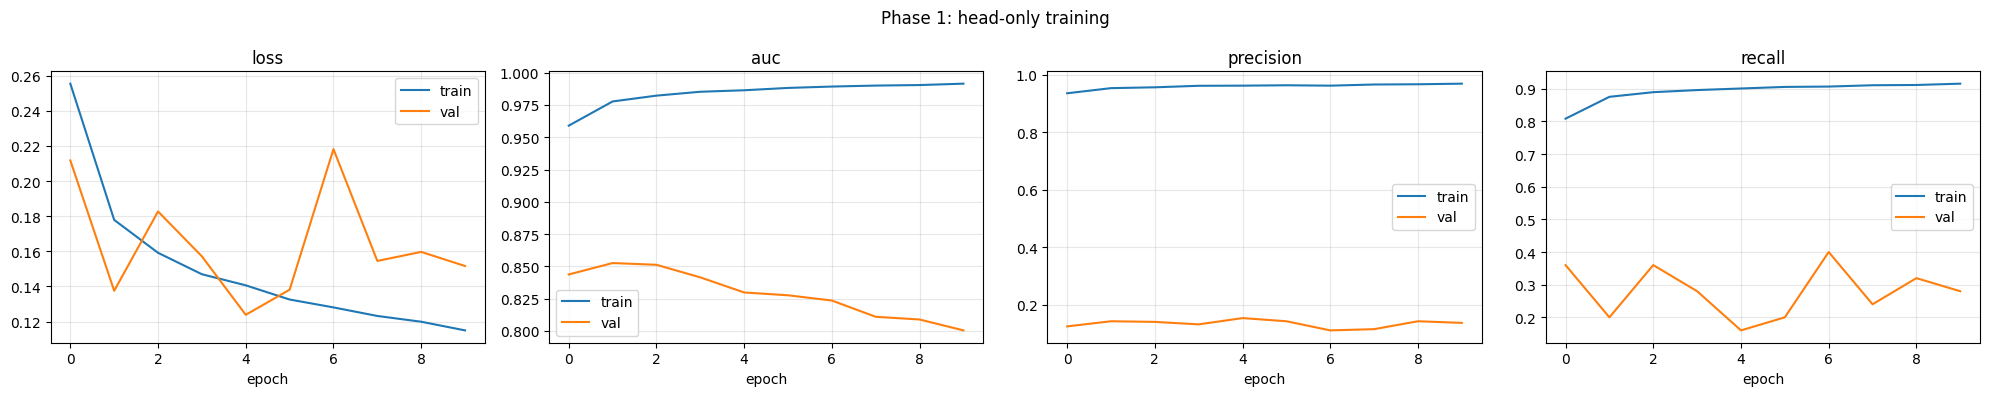

In [21]:
def plot_training_history(history, title):
    metrics = ['loss', 'auc', 'precision', 'recall']
    fig, axes = plt.subplots(1, len(metrics), figsize=(5 * len(metrics), 4))
    for ax, metric in zip(axes, metrics):
        ax.plot(history.history[metric], label='train')
        ax.plot(history.history[f'val_{metric}'], label='val')
        ax.set_title(metric)
        ax.set_xlabel('epoch')
        ax.legend()
        ax.grid(alpha=0.3)
    fig.suptitle(title)
    plt.tight_layout()
    plt.show()

plot_training_history(history, "Phase 1: head-only training")

## Fine-tune: unfreeze the last dense block

Phase 1 (above) trained only the new classification head with `base_model` fully frozen. Here, `conv5_block*` (DenseNet121's final dense block) is unfrozen so it can adapt to skin lesion images, while `conv2_block*`/`conv3_block*`/`conv4_block*` stay frozen — those learn generic low/mid-level features that transfer fine as-is. `BatchNormalization` layers inside `conv5_block*` are explicitly kept frozen too: letting their running stats update with this batch size and class imbalance destabilizes training. The model is recompiled with a much lower learning rate (1e-5 vs. the head-training default) since large updates at this stage would wreck the pretrained weights, and training continues from the phase-1 weights rather than from scratch.

In [22]:
# unfreeze only the last dense block; keep its BatchNorm layers frozen
for layer in base_model.layers:
    if layer.name.startswith('conv5_block'):
        layer.trainable = not isinstance(layer, layers.BatchNormalization)

model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-5),
    loss='binary_crossentropy',
    metrics=['accuracy', tf.keras.metrics.AUC(name='auc'), tf.keras.metrics.Precision(name='precision'), tf.keras.metrics.Recall(name='recall')],
)

model.summary()

# finetune_callbacks = [
#     tf.keras.callbacks.EarlyStopping(monitor='val_auc', mode='max', patience=3, restore_best_weights=True),
# ]

history_finetune = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=10,
    # callbacks=finetune_callbacks,
)

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ densenet121 (Functional)        │ (None, 1024)           │     7,037,504 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 1)              │         1,025 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 7,038,529 (26.85 MB)

 Trainable params: 2,130,945 (8.13 MB)

 Non-trainable params: 4,907,584 (18.72 MB)

Epoch 1/10
291/291 ━━━━━━━━━━━━━━━━━━━━ 103s 245ms/step - accuracy: 0.9602 - auc: 0.9938 - loss: 0.0999 - precision: 0.9684 - recall: 0.9310 - val_accuracy: 0.9634 - val_auc: 0.7677 - val_loss: 0.1238 - val_precision: 0.1538 - val_recall: 0.1600
Epoch 2/10
291/291 ━━━━━━━━━━━━━━━━━━━━ 32s 108ms/step - accuracy: 0.9759 - auc: 0.9977 - loss: 0.0677 - precision: 0.9805 - recall: 0.9589 - val_accuracy: 0.9498 - val_auc: 0.7867 - val_loss: 0.1435 - val_precision: 0.1600 - val_recall: 0.3200
Epoch 3/10
291/291 ━━━━━━━━━━━━━━━━━━━━ 38s 100ms/step - accuracy: 0.9861 - auc: 0.9990 - loss: 0.0465 - precision: 0.9891 - recall: 0.9761 - val_accuracy: 0.9660 - val_auc: 0.7603 - val_loss: 0.1144 - val_precision: 0.1429 - val_recall: 0.1200
Epoch 4/10
291/291 ━━━━━━━━━━━━━━━━━━━━ 29s 100ms/step - accuracy: 0.9925 - auc: 0.9997 - loss: 0.0322 - precision: 0.9932 - recall: 0.9879 - val_accuracy: 0.9694 - val_auc: 0.7751 - val_loss: 0.1125 - val_precision: 0.2381 - val_recall: 0.2000
Epoch 5/10
291/291 

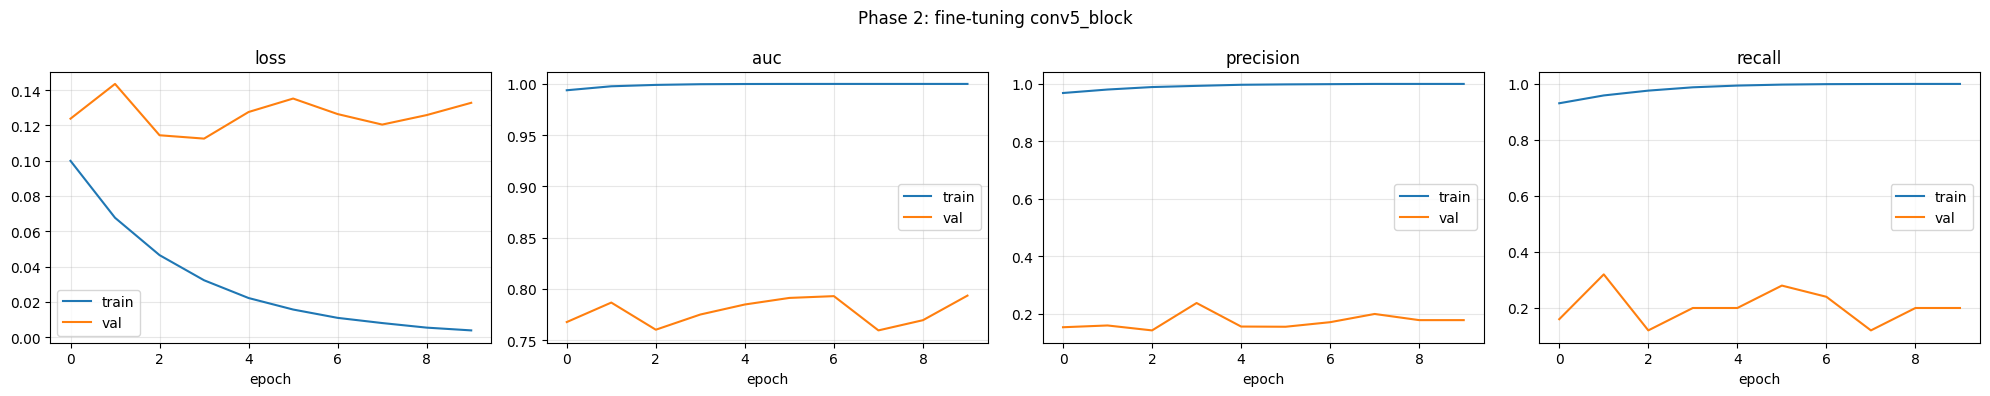

In [23]:
plot_training_history(history_finetune, "Phase 2: fine-tuning conv5_block")

In [24]:
from sklearn.metrics import classification_report, confusion_matrix

y_prob = model.predict(make_preprocessed_dataset(X_test)).ravel()
y_pred = (y_prob >= 0.01).astype(int)

print(classification_report(y_test, y_pred, target_names=['benign', 'malignant']))
print('confusion matrix:\n', confusion_matrix(y_test, y_pred))

37/37 ━━━━━━━━━━━━━━━━━━━━ 29s 427ms/step
              precision    recall  f1-score   support

      benign       0.99      0.86      0.92      1151
   malignant       0.09      0.64      0.16        25

    accuracy                           0.85      1176
   macro avg       0.54      0.75      0.54      1176
weighted avg       0.97      0.85      0.90      1176

confusion matrix:
 [[988 163]
 [  9  16]]


TP: 16, FN: 9


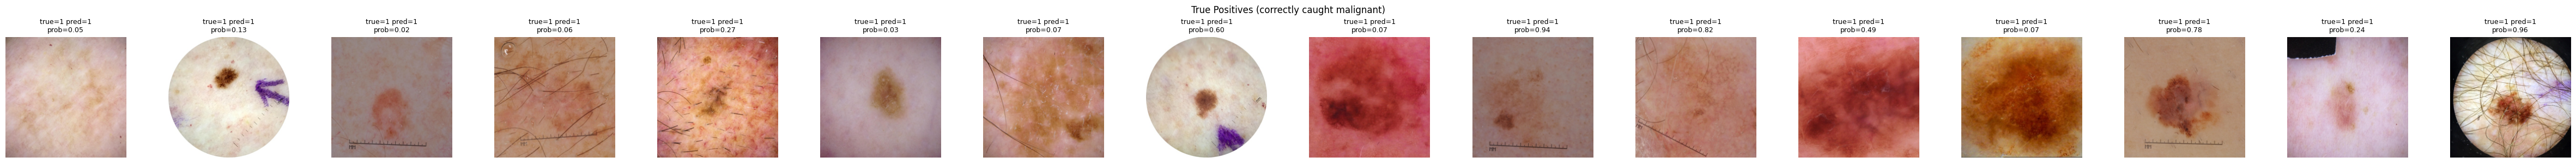

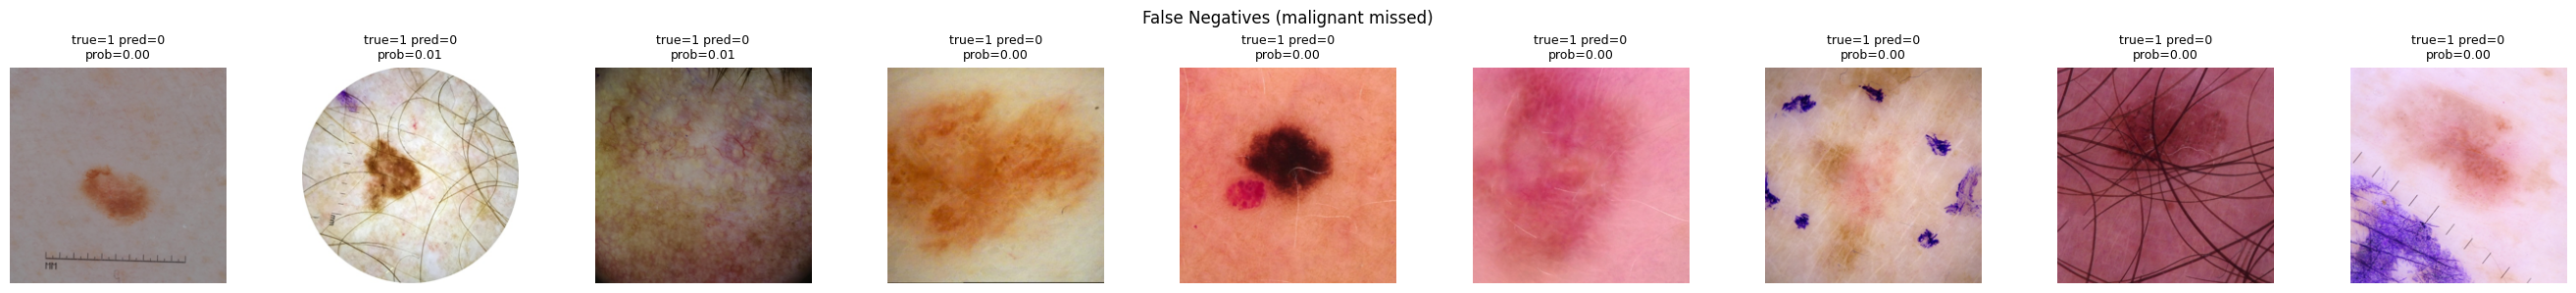

In [25]:
y_test_arr = np.asarray(y_test)
y_pred_arr = np.asarray(y_pred)

tp_idx = np.where((y_test_arr == 1) & (y_pred_arr == 1))[0]  # correctly caught malignant
fn_idx = np.where((y_test_arr == 1) & (y_pred_arr == 0))[0]  # malignant missed

print(f"TP: {len(tp_idx)}, FN: {len(fn_idx)}")

show_examples(tp_idx, X_test, y_test_arr, y_pred_arr, y_prob, "True Positives (correctly caught malignant)", n=len(tp_idx))
show_examples(fn_idx, X_test, y_test_arr, y_pred_arr, y_prob, "False Negatives (malignant missed)", n=len(fn_idx))